# AR, ARIMA, and SARIMA coverage comparison

## Abstract

This notebook is the aggregation point for the AR, ARIMA, and SARIMA coverage studies over the same retained KernelSynth and TimePFN LMC-Synth mechanisms. It reads the complete experiment record embedded in each executed notebook, harmonizes the method-specific results by benchmark mechanism and evaluation mode, and identifies cases that are not well covered by any configuration of any of the three model families. Once all branches have been executed, it plots a deterministic representative trajectory for every shared failure. Until then, it reports exactly which prerequisite notebooks are missing and withholds the cross-method conclusion.

A *shared failure* means that the same benchmark case fails the unchanged joint coverage criterion for AR, ARIMA, and SARIMA. Forecast error remains a separately reported diagnostic and does not replace the distributional coverage decision.

## Execution plan

1. **Freeze the common protocol.** Reuse the retained mechanisms, trajectories, seeds, train/test counts, lengths, metrics, thresholds, and best-configuration rule from the completed AR notebooks. A method family covers a case when at least one candidate configuration passes every coverage threshold.
2. **Preserve the AR baseline.** Keep the completed KernelSynth AR and LMC-Synth oracle-latent AR/end-to-end VAR results unchanged under `AR/`.
3. **Execute the ARIMA branch.** Create `ARIMA/01_kernelsynth_arima_coverage.ipynb` for an explicit `(p,d,q)` search and `ARIMA/02_timepfn_lmc_arima_varma_coverage.ipynb` for oracle-latent ARIMA and an end-to-end multivariate ARMA/VARMA analogue. Record convergence failures and the effective parameter count.
4. **Execute the SARIMA branch.** Create `SARIMA/01_kernelsynth_sarima_coverage.ipynb` for `(p,d,q)(P,D,Q)_s` and `SARIMA/02_timepfn_lmc_sarima_seasonal_var_coverage.ipynb` for oracle-latent SARIMA and the feasible end-to-end seasonal multivariate analogue. Report oracle-period and data-selected-period results separately.
5. **Run branch-level scientific checks.** Verify identical benchmark case identifiers, identical evaluation data, unchanged thresholds, deterministic seed derivation, convergence status, and complete experiment records. ARIMA and SARIMA may run in parallel after the common protocol is frozen.
6. **Aggregate only comparable cases.** Normalize each result to `(benchmark, mechanism, evaluation_mode, method_family, covered)` and intersect the cases observed in all three families.
7. **Plot shared failures.** Each new branch records a deterministic diagnostic trajectory for every failed case inside its experiment-record cell. This notebook plots all cases that fail AR, ARIMA, and SARIMA; when the intersection is empty, it states that explicitly.
8. **Interpret the remaining gap.** Separate failures associated with long periodicity, very smooth RBF behavior, composite kernels, temporal approximation, and multivariate mixing.

The ARIMA and SARIMA branches are parallelizable. Aggregation depends on both branches and on their two benchmark-specific notebooks.

In [1]:
from __future__ import annotations

import json
import platform
import subprocess
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display


def find_repo_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / 'pyproject.toml').exists() or (candidate / '.git').exists():
            return candidate
    raise FileNotFoundError('Could not locate the repository root.')


REPO_ROOT = find_repo_root(Path.cwd().resolve())
EXPERIMENT_ROOT = REPO_ROOT / 'experiments' / 'autoregressive_process_coverage'

EXPECTED_NOTEBOOKS = {
    'AR': [
        EXPERIMENT_ROOT / 'AR' / '01_kernelsynth_ar_coverage.ipynb',
        EXPERIMENT_ROOT / 'AR' / '02_timepfn_lmc_ar_var_coverage.ipynb',
    ],
    'ARIMA': [
        EXPERIMENT_ROOT / 'ARIMA' / '01_kernelsynth_arima_coverage.ipynb',
        EXPERIMENT_ROOT / 'ARIMA' / '02_timepfn_lmc_arima_varma_coverage.ipynb',
    ],
    'SARIMA': [
        EXPERIMENT_ROOT / 'SARIMA' / '01_kernelsynth_sarima_coverage.ipynb',
        EXPERIMENT_ROOT / 'SARIMA' / '02_timepfn_lmc_sarima_seasonal_var_coverage.ipynb',
    ],
}

print(f'Repository root: {REPO_ROOT}')
print(f'Experiment root: {EXPERIMENT_ROOT}')

Repository root: C:\Users\mateu\repos\tsfmxai
Experiment root: C:\Users\mateu\repos\tsfmxai\experiments\autoregressive_process_coverage


## Input contract and readiness

Every branch remains a self-contained executed notebook. The aggregator reads its labelled `COMPLETE EXPERIMENT RECORD`, so no duplicated configuration, manifest, or metrics sidecars are needed. KernelSynth records expose `best_row_per_function`; LMC-Synth records expose `best_row_per_mechanism_and_model`. New ARIMA and SARIMA records must preserve those schemas and add `diagnostic_series` for failed cases. Each diagnostic item contains `benchmark`, `mechanism`, `evaluation_mode`, and `values`, with multivariate values arranged as `[time, channel]`.

In [2]:
def output_text(output: dict) -> str:
    value = output.get('text', '')
    return ''.join(value) if isinstance(value, list) else value


def extract_experiment_record(path: Path) -> dict:
    notebook = json.loads(path.read_text(encoding='utf-8'))
    marker = 'COMPLETE EXPERIMENT RECORD'
    for cell in notebook.get('cells', []):
        for output in cell.get('outputs', []):
            text = output_text(output)
            marker_position = text.find(marker)
            if marker_position >= 0:
                json_position = text.find('{', marker_position + len(marker))
                if json_position >= 0:
                    record, _ = json.JSONDecoder().raw_decode(text[json_position:])
                    return record
    raise ValueError(f'No complete experiment record found in {path}.')


records = []
readiness_rows = []
for family, paths in EXPECTED_NOTEBOOKS.items():
    for path in paths:
        relative_path = path.relative_to(REPO_ROOT).as_posix()
        if not path.exists():
            readiness_rows.append({
                'method_family': family, 'notebook': relative_path,
                'state': 'missing', 'experiment_id': None,
            })
            continue
        try:
            record = extract_experiment_record(path)
            records.append((family, path, record))
            readiness_rows.append({
                'method_family': family, 'notebook': relative_path,
                'state': 'ready', 'experiment_id': record.get('experiment_id'),
            })
        except Exception as exc:
            readiness_rows.append({
                'method_family': family, 'notebook': relative_path,
                'state': f'invalid: {exc}', 'experiment_id': None,
            })

readiness = pd.DataFrame(readiness_rows)
display(readiness)

,method_family,notebook,state,experiment_id
0,AR,experiments/autoregressive_process_coverage/AR...,ready,kernelsynth_ar_coverage_002
1,AR,experiments/autoregressive_process_coverage/AR...,ready,timepfn_lmc_ar_var_coverage_002
2,ARIMA,experiments/autoregressive_process_coverage/AR...,ready,kernelsynth_arima_css_coverage_001
3,ARIMA,experiments/autoregressive_process_coverage/AR...,ready,timepfn_lmc_arima_varma_css_coverage_001
4,SARIMA,experiments/autoregressive_process_coverage/SA...,ready,kernelsynth_sarima_css_coverage_001
5,SARIMA,experiments/autoregressive_process_coverage/SA...,ready,timepfn_lmc_sarima_seasonal_var_css_coverage_001


## Harmonized coverage table

The comparison unit is a retained benchmark case. KernelSynth has one univariate case per kernel mechanism. LMC-Synth has two evaluation modes per retained mechanism: `oracle_latent`, which tests temporal approximation before mixing, and `end_to_end`, which tests the observed multivariate process. Model-specific names such as AR, VAR, ARIMA, VARMA, and seasonal variants are normalized to those stable evaluation modes.

,benchmark,mechanism,evaluation_mode,method_family,covered,best_configuration
0,kernelsynth,composite_01,univariate,AR,True,4
1,kernelsynth,composite_02,univariate,AR,True,256
2,kernelsynth,composite_03,univariate,AR,False,32
3,kernelsynth,composite_04,univariate,AR,True,256
4,kernelsynth,composite_05,univariate,AR,True,16
5,kernelsynth,composite_06,univariate,AR,False,128
6,kernelsynth,composite_07,univariate,AR,True,64
7,kernelsynth,composite_08,univariate,AR,True,64
8,kernelsynth,composite_09,univariate,AR,True,32
9,kernelsynth,composite_10,univariate,AR,True,32


Normalized rows currently available: 225
Ready method families: ['AR', 'ARIMA', 'SARIMA']
Method families still required: []


method_family                   AR  ARIMA  SARIMA
benchmark   evaluation_mode                      
kernelsynth univariate       0.906  0.906   0.547
lmc_synth   end_to_end       0.727  0.727   0.545
            oracle_latent    0.727  0.818   0.364

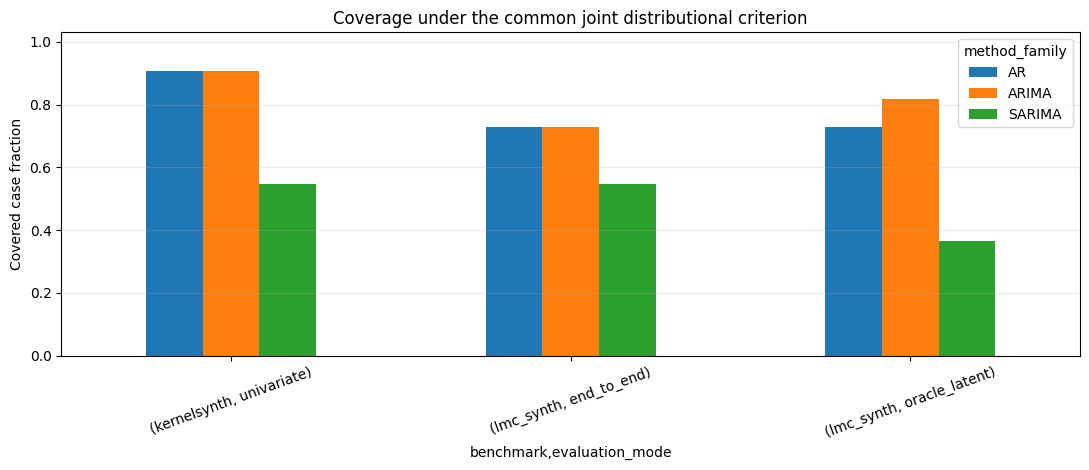

In [3]:
def normalize_record(family: str, record: dict) -> list[dict]:
    metrics = record.get('metrics', {})
    normalized = []
    for row in metrics.get('best_row_per_function', []):
        normalized.append({
            'benchmark': 'kernelsynth',
            'mechanism': row['function'],
            'evaluation_mode': 'univariate',
            'method_family': family,
            'covered': bool(row['well_covered_any_order']),
            'best_configuration': row.get('order', row.get('configuration')),
        })
    for row in metrics.get('best_row_per_mechanism_and_model', []):
        model_name = str(row['model']).lower()
        evaluation_mode = 'oracle_latent' if 'oracle_latent' in model_name else 'end_to_end'
        normalized.append({
            'benchmark': 'lmc_synth',
            'mechanism': row['mechanism'],
            'evaluation_mode': evaluation_mode,
            'method_family': family,
            'covered': bool(row['well_covered_any_order']),
            'best_configuration': row.get('order', row.get('configuration')),
        })
    return normalized


comparison_rows = [
    row
    for family, _, record in records
    for row in normalize_record(family, record)
]
comparison = pd.DataFrame(comparison_rows)
required_families = set(EXPECTED_NOTEBOOKS)
ready_families = {
    family for family, paths in EXPECTED_NOTEBOOKS.items()
    if all(any(record_path == path for _, record_path, _ in records) for path in paths)
}
missing_families = sorted(required_families - ready_families)

if comparison.empty:
    print('No normalized results are available.')
else:
    display(comparison.head(12))
    print(f'Normalized rows currently available: {len(comparison)}')
print(f'Ready method families: {sorted(ready_families)}')
print(f'Method families still required: {missing_families}')

coverage_summary = pd.DataFrame()
if not comparison.empty:
    coverage_summary = (comparison.groupby(
        ['benchmark', 'evaluation_mode', 'method_family']
    )['covered'].mean().unstack('method_family').reindex(columns=['AR', 'ARIMA', 'SARIMA']))
    display(coverage_summary.round(3))
    axis = coverage_summary.plot.bar(figsize=(11, 4.8), rot=20)
    axis.set_ylim(0, 1.03)
    axis.set_ylabel('Covered case fraction')
    axis.set_title('Coverage under the common joint distributional criterion')
    axis.grid(axis='y', alpha=0.25)
    plt.tight_layout(); plt.show()

## Coverage comparison and mechanisms missed by all three families

The table and grouped bars above compare AR, ARIMA, and SARIMA separately for KernelSynth, oracle-latent LMC, and end-to-end LMC. The intersection below is computed only after all six prerequisite notebooks are ready. This prevents a missing branch from being interpreted as a model failure. For every shared failure, the plot shows the deterministic diagnostic trajectory retained by a failed ARIMA or SARIMA experiment record. Multivariate cases show every observed channel in the same panel.

method_family,benchmark,mechanism,evaluation_mode,AR,ARIMA,SARIMA
0,kernelsynth,composite_06,univariate,False,False,False
1,kernelsynth,composite_13,univariate,False,False,False
2,lmc_synth,lmc_04,end_to_end,False,False,False
3,lmc_synth,lmc_04,oracle_latent,False,False,False
4,lmc_synth,lmc_09,end_to_end,False,False,False


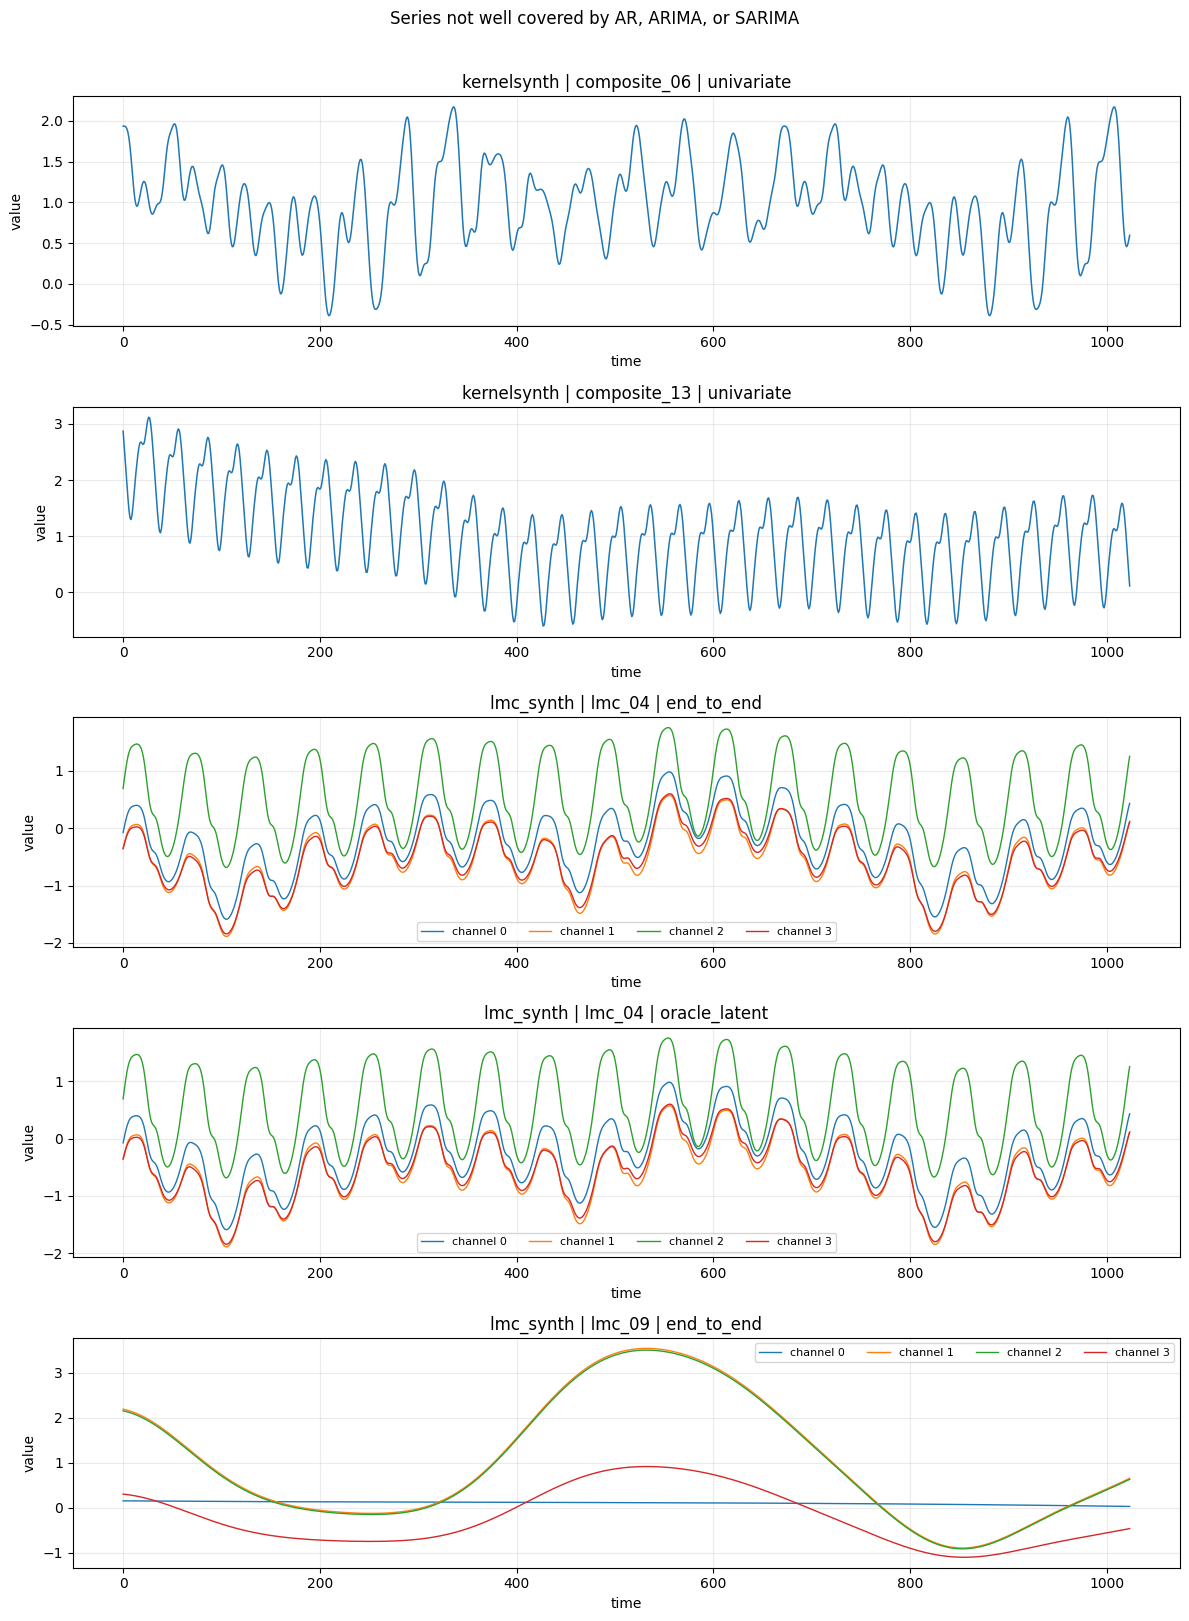

In [4]:
shared_failures = pd.DataFrame()
if missing_families:
    print('Shared-failure analysis withheld until every method family is ready.')
else:
    index_columns = ['benchmark', 'mechanism', 'evaluation_mode']
    coverage_matrix = comparison.pivot_table(
        index=index_columns, columns='method_family', values='covered', aggfunc='first'
    )
    complete_cases = coverage_matrix.dropna(subset=sorted(required_families))
    shared_failures = complete_cases.loc[~complete_cases[list(sorted(required_families))].any(axis=1)].reset_index()
    if shared_failures.empty:
        print('No benchmark case failed AR, ARIMA, and SARIMA simultaneously.')
    else:
        display(shared_failures)

        diagnostic_lookup = {}
        for _, _, record in records:
            for item in record.get('diagnostic_series', []):
                key = (item['benchmark'], item['mechanism'], item['evaluation_mode'])
                diagnostic_lookup.setdefault(key, np.asarray(item['values'], dtype=float))

        figure_rows = []
        for row in shared_failures.to_dict('records'):
            key = (row['benchmark'], row['mechanism'], row['evaluation_mode'])
            if key not in diagnostic_lookup:
                raise ValueError(f'Missing diagnostic trajectory for shared failure {key}.')
            figure_rows.append((key, diagnostic_lookup[key]))

        fig, axes = plt.subplots(len(figure_rows), 1, figsize=(12, 3.2 * len(figure_rows)), squeeze=False)
        for axis, (key, values) in zip(axes[:, 0], figure_rows):
            if values.ndim == 1:
                axis.plot(values, linewidth=1.1, label='series')
            elif values.ndim == 2:
                for channel in range(values.shape[1]):
                    axis.plot(values[:, channel], linewidth=1.0, label=f'channel {channel}')
                axis.legend(ncol=min(4, values.shape[1]), fontsize=8)
            else:
                raise ValueError(f'Unexpected diagnostic shape {values.shape} for {key}.')
            axis.set_title(' | '.join(key))
            axis.set_xlabel('time')
            axis.set_ylabel('value')
            axis.grid(alpha=0.25)
        fig.suptitle('Series not well covered by AR, ARIMA, or SARIMA', y=1.01)
        fig.tight_layout()
        plt.show()

In [5]:
def git_output(*args: str) -> str:
    try:
        return subprocess.check_output(['git', *args], cwd=REPO_ROOT, text=True).strip()
    except Exception as exc:
        return f'unavailable: {exc}'


record = {
    'experiment_id': 'ar_arima_sarima_aggregation_001' if not missing_families else 'ar_arima_sarima_aggregation_readiness_001',
    'status': 'completed' if not missing_families else 'readiness_check_completed',
    'research_question': 'Which retained KernelSynth and LMC-Synth cases are not well covered by any tested AR, ARIMA, or SARIMA configuration?',
    'hypothesis': 'ARIMA should resolve some trend and moving-average failures of AR, while SARIMA should resolve some explicitly periodic failures; smooth and composite GP mechanisms may remain outside all three bounded searches.',
    'configuration': {
        'required_method_families': sorted(required_families),
        'required_notebooks': {family: [path.relative_to(REPO_ROOT).as_posix() for path in paths] for family, paths in EXPECTED_NOTEBOOKS.items()},
        'comparison_key': ['benchmark', 'mechanism', 'evaluation_mode'],
        'shared_failure_rule': 'covered is false for AR, ARIMA, and SARIMA after selecting the best valid configuration inside each family',
    },
    'provenance': {
        'project_head': git_output('rev-parse', 'HEAD'),
        'inputs': readiness.to_dict('records'),
    },
    'seed_usage': {
        'aggregation': 'no stochastic computation',
        'plots': 'reuse deterministic diagnostic trajectories retained by branch experiment records',
    },
    'environment': {
        'python': sys.version,
        'platform': platform.platform(),
        'numpy': np.__version__,
        'pandas': pd.__version__,
    },
    'metrics': {
        'ready_method_families': sorted(ready_families),
        'missing_method_families': missing_families,
        'normalized_rows_available': int(len(comparison)),
        'shared_failure_count': None if missing_families else int(len(shared_failures)),
        'shared_failures': None if missing_families else shared_failures.to_dict('records'),
        'coverage_summary': coverage_summary.reset_index().to_dict('records'),
    },
    'scientific_summary': (
        'The completed AR records were discovered and normalized. Cross-method conclusions and plots are deliberately withheld until both ARIMA and SARIMA branches are complete.'
        if missing_families else
        f'All method families are ready; {len(shared_failures)} shared failures were identified.'
    ),
    'limitations': [
        'This execution is a readiness result while ARIMA and SARIMA notebooks are absent.',
        'Final conclusions require identical retained mechanisms, trajectories, thresholds, and comparison keys across branches.',
    ] if missing_families else [
        'The finite retained mechanisms do not exhaust the KernelSynth or LMC-Synth priors.',
        'Coverage thresholds remain operational choices that require sensitivity analysis.',
        'ARIMA and seasonal models use pooled CSS; seasonal lag support is expanded without exact nonlinear multiplicative parameter constraints.',
    ],
    'reproduction': {
        'command': r'.\.venv\Scripts\jupyter.exe nbconvert --to notebook --execute experiments\autoregressive_process_coverage\00_ar_arima_sarima_comparison.ipynb --output 00_ar_arima_sarima_comparison.ipynb --ExecutePreprocessor.timeout=3600',
    },
}

print('COMPLETE EXPERIMENT RECORD')
print(json.dumps(record, indent=2))

COMPLETE EXPERIMENT RECORD
{
  "experiment_id": "ar_arima_sarima_aggregation_001",
  "status": "completed",
  "research_question": "Which retained KernelSynth and LMC-Synth cases are not well covered by any tested AR, ARIMA, or SARIMA configuration?",
  "hypothesis": "ARIMA should resolve some trend and moving-average failures of AR, while SARIMA should resolve some explicitly periodic failures; smooth and composite GP mechanisms may remain outside all three bounded searches.",
  "configuration": {
    "required_method_families": [
      "AR",
      "ARIMA",
      "SARIMA"
    ],
    "required_notebooks": {
      "AR": [
        "experiments/autoregressive_process_coverage/AR/01_kernelsynth_ar_coverage.ipynb",
        "experiments/autoregressive_process_coverage/AR/02_timepfn_lmc_ar_var_coverage.ipynb"
      ],
      "ARIMA": [
        "experiments/autoregressive_process_coverage/ARIMA/01_kernelsynth_arima_coverage.ipynb",
        "experiments/autoregressive_process_coverage/ARIMA/02_t